In [7]:
# imports
import HTSeq
import numpy as np
import pandas as pd

from price2.cleavage_model import CleavageModel
from orf_activity_estimator import ORFActivityEstimator

from matplotlib import pyplot as plt

In [8]:
gtf_path = 'data/ORF_NOISE_simple.gtf'

pl = np.array(pd.read_csv('data/upstream_cleavage_model', sep='\t', header=None)[0])
pr = np.array(pd.read_csv('data/downstream_cleavage_model', sep='\t', header=None)[0])

cm = CleavageModel(pl, pr, 0.1080613528993745)

orf_estimator = ORFActivityEstimator(
    cm,
    reads_path='data/ORF_NOISE_simple.sam',
    gtf_path=gtf_path,
    maxiter=50,
    delta_cutoff=.01,
)

In [9]:
orf_estimator.fill_association_classes()

In [10]:
orf_estimator.run_orf_deconvolution(iterations=500)

break at iteration  94


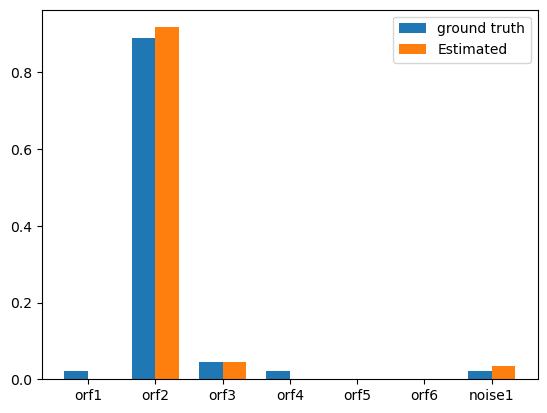

In [11]:
from fractions import Fraction

ground_truth = [float(Fraction(region.attr['activity'])) for region in HTSeq.GFF_Reader(gtf_path)]

estimated = [orf_estimator.regions[region_id].activity for region_id in orf_estimator.regions]
estimated = [x/sum(estimated) for x in estimated]

tick_labels = [region.attr['region_id'] for region in HTSeq.GFF_Reader(gtf_path)]

bar_width = 0.35

plt.bar([x-bar_width/2 for x in range(1,len(ground_truth)+1)], ground_truth, width=bar_width, label='ground truth')
plt.bar([x+bar_width/2 for x in range(1,len(ground_truth)+1)], estimated, width=bar_width, label='Estimated')
plt.legend()
plt.xticks([x for x in range(1,len(ground_truth)+1)], tick_labels)
pass

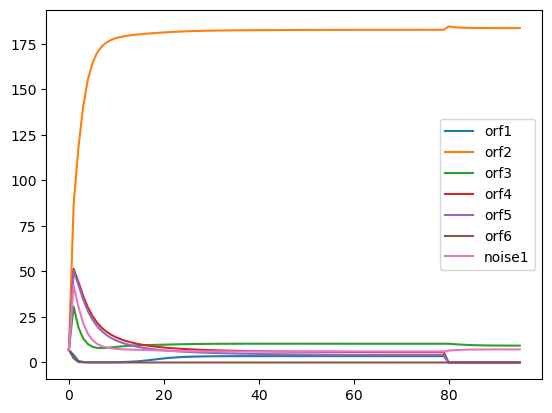

In [12]:
for region_id in orf_estimator.regions:
    plt.plot(orf_estimator.region_activities[region_id], label=region_id)
plt.legend()